# **Hangman**

In dit notebook bouwen we stap voor stap een steeds slimmere **rule-based agent** voor het spel Hangman. We beginnen bij een agent die volledig willekeurig gokt en eindigen bij een agent die op basis van **informatietheorie** de optimale letter kiest.

Elke strategie voegt precies één laag kennis of redenering toe boven de vorige:

| # | Strategie | Kernidee |
|---|---|---|
| 1 | **Random** | Willekeurige letter — puur toeval |
| 2 | **Frequentie** | Letters in volgorde van Engelse letterfrequentie |
| 3 | **Positionele Frequentie** | Letterfrequentie *per positie* in de woordenlijst |
| 4 | **Woordeliminatie** | Actief filteren van onmogelijke woorden na elke gok |
| 5 | **Entropie** | Letter kiezen die de kandidatenlijst het meest *informatief* opsplitst |

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())

import math
import random
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from IPython.display import clear_output, display, Markdown, HTML

try:
    import ipywidgets as widgets
    HAS_WIDGETS = True
except Exception:
    HAS_WIDGETS = False

from environment import HangmanEnvironment
from agents import (
    RandomAgent, FrequencyAgent, PositionalFrequencyAgent,
    WordListEliminationAgent, EntropyAgent, get_all_agents
)
from benchmark import load_word_list

warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
# -- Drawing helpers --------------------------------------------------------
PALETTE = {
    "bg":         "#1A1A2E",
    "panel":      "#16213E",
    "accent":     "#E94560",
    "correct":    "#0F9B58",
    "wrong":      "#E94560",
    "guessed":    "#2980B9",
    "neutral":    "#2C2C54",
    "text":       "#EAEAEA",
    "subtext":    "#A0A0C0",
    "gold":       "#F4D03F",
    "gallows":    "#C0C0D0",
}

AGENT_COLOR_MAP = {
    "Random Agent": "#E67E22",
    "Frequency Agent": "#3498DB",
    "Positional Frequency Agent": "#9B59B6",
    "Word List Elimination Agent": "#0F9B58",
    "Entropy Agent": "#F4D03F",
}


def agent_color(agent_name: str) -> str:
    """Consistent color per strategy across all plots."""
    return AGENT_COLOR_MAP.get(agent_name, PALETTE["guessed"])


def apply_plot_theme():
    """Set one shared matplotlib style for all static visualizations."""
    plt.rcParams.update({
        "figure.facecolor": PALETTE["bg"],
        "savefig.facecolor": PALETTE["bg"],
        "axes.facecolor": PALETTE["panel"],
        "axes.edgecolor": "#FFFFFF22",
        "axes.labelcolor": PALETTE["text"],
        "axes.titlecolor": PALETTE["text"],
        "xtick.color": PALETTE["subtext"],
        "ytick.color": PALETTE["subtext"],
        "text.color": PALETTE["text"],
        "grid.color": "#FFFFFF22",
        "legend.facecolor": PALETTE["panel"],
        "legend.edgecolor": "#FFFFFF22",
    })


def style_axis(ax, x_rotation=0, grid_axis="y"):
    """Apply consistent axis styling for benchmark charts."""
    ax.set_facecolor(PALETTE["panel"])
    for spine in ax.spines.values():
        spine.set_color("#FFFFFF22")
    ax.tick_params(axis="x", colors=PALETTE["subtext"], rotation=x_rotation)
    ax.tick_params(axis="y", colors=PALETTE["subtext"])
    if grid_axis:
        ax.grid(axis=grid_axis, alpha=0.25)


def style_legend(ax, **kwargs):
    """Create a legend that matches the notebook dark theme."""
    leg = ax.legend(**kwargs)
    if leg is not None:
        frame = leg.get_frame()
        frame.set_facecolor(PALETTE["panel"])
        frame.set_edgecolor("#FFFFFF22")
        for txt in leg.get_texts():
            txt.set_color(PALETTE["text"])
    return leg


apply_plot_theme()


def draw_gallows(ax, wrong: int, max_wrong: int = 10):
    """Draw the hangman figure - dark-theme style."""
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 12)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_facecolor(PALETTE["panel"])

    lw_frame = 3.5
    gc = PALETTE["gallows"]

    # base
    ax.plot([1, 9], [1, 1],   color=gc, lw=lw_frame, solid_capstyle='round')
    # pole
    ax.plot([3, 3], [1, 11],  color=gc, lw=lw_frame, solid_capstyle='round')
    # top beam
    ax.plot([3, 7], [11, 11], color=gc, lw=lw_frame, solid_capstyle='round')
    # diagonal brace
    ax.plot([3, 5.2], [8.5, 11], color=gc, lw=2, alpha=0.5, solid_capstyle='round')
    # rope
    ax.plot([7, 7], [11, 9.6], color=gc, lw=2, solid_capstyle='round')

    # Progress dots along base (remaining lives)
    remaining = max_wrong - wrong
    for i in range(max_wrong):
        dot_color = PALETTE["correct"] if i < remaining else PALETTE["wrong"]
        ax.plot(1.0 + i * (8.0 / (max_wrong - 1)), 0.4,
                'o', color=dot_color, markersize=4)

    dead = wrong >= max_wrong
    body_color = PALETTE["wrong"] if dead else PALETTE["text"]
    lw_body = 2.5

    parts = [
        # (min_wrong, draw_fn)
        (1, lambda: ax.add_patch(
            plt.Circle((7, 8.85), 0.75, color=body_color, fill=False, lw=lw_body))),
        (2, lambda: ax.plot([7, 7], [8.1, 5.5],  color=body_color, lw=lw_body, solid_capstyle='round')),
        (3, lambda: ax.plot([7, 5.0], [7.4, 6.0], color=body_color, lw=lw_body, solid_capstyle='round')),
        (4, lambda: ax.plot([7, 9.0], [7.4, 6.0], color=body_color, lw=lw_body, solid_capstyle='round')),
        (5, lambda: ax.plot([7, 5.3], [5.5, 3.8], color=body_color, lw=lw_body, solid_capstyle='round')),
        (6, lambda: ax.plot([7, 8.7], [5.5, 3.8], color=body_color, lw=lw_body, solid_capstyle='round')),
        (7, lambda: ax.plot([5.3, 4.2], [3.8, 3.8], color=body_color, lw=lw_body, solid_capstyle='round')),
        (8, lambda: ax.plot([8.7, 9.8], [3.8, 3.8], color=body_color, lw=lw_body, solid_capstyle='round')),
        (9, lambda: ax.plot([5.3, 4.8], [3.8, 2.8], color=body_color, lw=lw_body, solid_capstyle='round')),
        (10, lambda: ax.plot([8.7, 9.2], [3.8, 2.8], color=body_color, lw=lw_body, solid_capstyle='round')),
    ]
    for threshold, fn in parts:
        if wrong >= threshold:
            fn()

    # Face expressions when dead
    if dead:
        ax.text(6.65, 8.9, "x", ha='center', va='center',
                fontsize=9, color=PALETTE["wrong"], fontweight='bold')
        ax.text(7.35, 8.9, "x", ha='center', va='center',
                fontsize=9, color=PALETTE["wrong"], fontweight='bold')
        ax.text(7.0, 8.4, "~", ha='center', va='center',
                fontsize=10, color=PALETTE["wrong"])


def draw_word(ax, masked_word: str, won: bool, secret_word: str = ""):
    """Draw the masked/revealed word as letter tiles - dark theme."""
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_facecolor(PALETTE["panel"])

    n = len(masked_word)
    tile_w = min(0.88 / n, 0.11)
    gap = tile_w * 0.25
    total = n * tile_w + (n - 1) * gap
    x0 = (1 - total) / 2

    for i, ch in enumerate(masked_word):
        x = x0 + i * (tile_w + gap)
        revealed = ch != '_'
        if won and revealed:
            bg = PALETTE["correct"]
            edge = "#0D7A45"
        elif revealed:
            bg = "#1C5E8A"
            edge = "#2980B9"
        else:
            bg = PALETTE["neutral"]
            edge = "#3C3C6E"

        rect = mpatches.FancyBboxPatch(
            (x, 0.22), tile_w, 0.56,
            boxstyle='round,pad=0.015',
            facecolor=bg, edgecolor=edge, lw=1.5
        )
        ax.add_patch(rect)
        if revealed:
            ax.text(x + tile_w / 2, 0.50, ch.upper(),
                    ha='center', va='center', fontsize=13,
                    fontweight='bold', color='white')
        else:
            # Underscore hint
            ax.plot([x + tile_w * 0.15, x + tile_w * 0.85], [0.24, 0.24],
                    color="#5C5C8A", lw=1.5)


def draw_letters(ax, guessed: set, secret_word: str, remaining: list):
    """Draw the alphabet - dark-theme coloured tiles."""
    ax.set_xlim(0, 26)
    ax.set_ylim(0, 2)
    ax.axis('off')
    ax.set_facecolor(PALETTE["bg"])

    alphabet = 'abcdefghijklmnopqrstuvwxyz'
    for i, ch in enumerate(alphabet):
        if ch in guessed:
            if ch in secret_word:
                bg, tc, edge = PALETTE["correct"], "white", "#0A7040"
            else:
                bg, tc, edge = PALETTE["wrong"], "white", "#B03040"
        else:
            bg, tc, edge = PALETTE["neutral"], PALETTE["subtext"], "#3C3C6E"

        rect = mpatches.FancyBboxPatch(
            (i + 0.08, 0.15), 0.84, 1.2,
            boxstyle='round,pad=0.05',
            facecolor=bg, edgecolor=edge, lw=0.8
        )
        ax.add_patch(rect)
        ax.text(i + 0.5, 0.75, ch.upper(),
                ha='center', va='center', fontsize=8,
                fontweight='bold', color=tc)


def _progress_bar(ax, wrong, max_wrong):
    """Small horizontal lives bar in the word panel."""
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    frac = max(0, (max_wrong - wrong) / max_wrong)
    # Background
    ax.barh(0.5, 1.0, height=0.35, color="#2C2C54", left=0)
    # Filled
    bar_color = PALETTE["correct"] if wrong < max_wrong * 0.5 else \
                PALETTE["gold"]   if wrong < max_wrong * 0.8 else \
                PALETTE["wrong"]
    ax.barh(0.5, frac, height=0.35, color=bar_color, left=0)
    ax.text(0.5, 0.5, f"{max_wrong - wrong} / {max_wrong} lives",
            ha='center', va='center', fontsize=8,
            color="white", fontweight='bold')


def render_state(obs, game, agent_name, step, reward, total_reward, event, delay=0.6):
    """Full-page render of the current game state - dark theme."""
    fig = plt.figure(figsize=(13, 7), facecolor=PALETTE["bg"])

    # Layout: title | gallows + (word + lives + letters)
    outer = gridspec.GridSpec(2, 1, figure=fig,
                              height_ratios=[0.12, 0.88], hspace=0.08)
    inner = gridspec.GridSpecFromSubplotSpec(
        2, 2, subplot_spec=outer[1],
        height_ratios=[0.72, 0.28],
        width_ratios=[0.42, 0.58],
        hspace=0.22, wspace=0.18
    )

    wrong      = obs['wrong_guesses']
    max_wrong  = obs['max_wrong_guesses']
    masked     = obs['masked_word']
    guessed    = set(obs['guessed_letters'])
    secret     = game.secret_word

    # Title bar
    ax_title = fig.add_subplot(outer[0])
    ax_title.set_facecolor(PALETTE["panel"])
    ax_title.axis('off')

    if obs['is_won']:
        status_str = "  ✓  YOU WIN!"
        title_color = PALETTE["correct"]
    elif obs['is_lost']:
        status_str = f"  ✗  GAME OVER  (word: {secret.upper()})"
        title_color = PALETTE["wrong"]
    else:
        status_str = ""
        title_color = PALETTE["text"]

    # Agent / step info (left)
    ax_title.text(0.02, 0.5,
                  f"  {agent_name}   |   Step {step}   |   {event}",
                  ha='left', va='center', fontsize=10.5,
                  color=PALETTE["subtext"], transform=ax_title.transAxes)
    # Reward (right)
    rew_color = PALETTE["correct"] if reward >= 0 else PALETTE["wrong"]
    ax_title.text(0.98, 0.5,
                  f"Reward: {reward:+.1f}   Total: {total_reward:+.1f}{status_str}",
                  ha='right', va='center', fontsize=10.5,
                  color=rew_color, fontweight='bold',
                  transform=ax_title.transAxes)
    # Coloured status overlay
    if status_str:
        ax_title.set_facecolor(
            "#0B3D1F" if obs['is_won'] else "#3D0B0B"
        )

    # Gallows
    ax_gallows = fig.add_subplot(inner[0, 0])
    ax_gallows.set_facecolor(PALETTE["panel"])
    draw_gallows(ax_gallows, wrong, max_wrong)
    ax_gallows.set_title(
        f"Wrong: {wrong} / {max_wrong}",
        fontsize=10, color=PALETTE["subtext"], pad=4,
    )

    # Word tiles
    ax_word = fig.add_subplot(inner[0, 1])
    ax_word.set_facecolor(PALETTE["panel"])
    draw_word(ax_word, masked, obs['is_won'], secret)
    hidden = masked.count("_")
    ax_word.set_title(
        f"{len(masked)}-letter word   |   {hidden} hidden",
        fontsize=10, color=PALETTE["subtext"], pad=4,
    )

    # Lives bar
    ax_lives = fig.add_subplot(inner[1, 0])
    ax_lives.set_facecolor(PALETTE["panel"])
    _progress_bar(ax_lives, wrong, max_wrong)

    # Letter grid
    ax_letters = fig.add_subplot(inner[1, 1])
    ax_letters.set_facecolor(PALETTE["bg"])
    draw_letters(ax_letters, guessed, secret, obs['remaining_letters'])

    plt.show()
    if delay:
        time.sleep(delay)

## 1. De vijf strategieën

Hieronder beschrijven we elke strategie in detail. Elke agent bouwt voort op de voorgaande, waardoor er een duidelijke opbouw ontstaat.

---

### Strategie 1: Random agent
De eenvoudigste aanpak: kies elke beurt een **willekeurige letter** uit de nog niet geraden letters. Er wordt géén gebruik gemaakt van de woordenlijst of enige andere kennis. Dit is onze **baseline**, alles wat slechter scoort is erger dan puur toeval.

---

### Strategie 2: Frequentie agent
In het Engels komen bepaalde letters veel vaker voor dan andere. De frequentievolgorde is (Norvig, 2012):  
`E → T → A → O → I → N → S → H → R → D → …`

Deze agent gokt letters in die vaste volgorde, ongeacht welk woord gespeeld wordt. Het is beter dan willekeurig omdat veelvoorkomende letters vaker correct zijn, maar de agent **negeert de woordenlijst** volledig — hij past zijn strategie niet aan op basis van het spel.

---

### Strategie 3: Positionele frequentie agent
Deze agent gebruikt wél de woordenlijst, maar op een statistische manier. Voor elke **onbekende positie** in het masker telt hij hoe vaak iedere letter op die plek voorkomt in alle woorden van dezelfde lengte.

**Verschil met strategie 2:** de keuze hangt af van *waar* de onbekende letters zitten. Een letter die vaak op positie 1 staat weegt zwaarder als positie 1 nog onbekend is.

**Beperking:** er wordt niet actief gefilterd op het huidige spelverloop — woorden die al onmogelijk zijn (door eerdere gokken) tellen nog steeds mee.

---

### Strategie 4: Woordeliminatie agent
Hier begint de agent écht na te denken over het spel. Na elke gok wordt de woordenlijst **gefilterd**: woorden die niet meer passen bij het huidige masker en de geraden letters worden verwijderd. Dit levert een steeds kleinere **kandidatenlijst** op.

De agent kiest vervolgens de letter die in de **meeste resterende kandidaten** voorkomt. Dit maximaliseert de kans op een correcte gok.

**Groot verschil met strategie 3:** de kandidatenlijst krimpt dynamisch na elke beurt, waardoor latere gokken steeds gerichter worden.

---

### Strategie 5: Entropie agent
De entropie-agent filtert kandidaten op dezelfde manier als strategie 4, maar maakt een slimmere keuze. In plaats van simpelweg de meest-voorkomende letter te kiezen, berekent hij voor elke letter de **Shannon-entropie** van de opsplitsing die die letter zou veroorzaken (Shannon, 1948).

**Waarom is dit beter?** Twee letters kunnen allebei in 80% van de kandidaten voorkomen, maar ze splitsen de lijst heel anders op:

| Scenario | Letter A | Letter B |
|---|---|---|
| Hit-groepen | 40% + 40% | 70% + 10% |
| Informatiewinst | **Hoog** (twee even grote groepen) | Laag (één grote, één kleine) |

De entropie-agent kiest letter A, ook al hebben beide dezelfde kans op een hit, omdat A meer informatie oplevert ongeacht de uitkomst (Cover & Thomas, 2006).

**Life-aware gedrag:** bij het allerlaatste leven schakelt de agent over naar een **overlevingsmodus**: een fout betekent dan direct verlies. In dat geval weegt de agent niet alleen informatie maar ook de **kans op een correcte gok** mee, zodat hij niet sterft door een informatief-maar-riskant vermoeden.

De gebruikte formule (Shannon-entropie):

$$H = -\sum_{i} p_i \log_2 p_i$$

waarbij $p_i$ het aandeel kandidaten in elke patroongroep is (Shannon, 1948).

## 2. Environment-opzet en woordenlijst

De HangmanEnvironment wordt gevoed met woorden uit `words.txt`. De woordenlijst bevat woorden van 4 tot 10 letters en is bewust samengesteld met **confusable groepen** (bijv. `-ight`, `-atch`, `-ness`), zodat strategieverschillen duidelijk zichtbaar worden in de resultaten.

In [3]:
FIXED_WORDS = load_word_list("words.txt")

length_dist = Counter(len(w) for w in FIXED_WORDS)
total = len(FIXED_WORDS)
print(f"Vaste woordenlijst: {total} unieke woorden")
for length, count in sorted(length_dist.items()):
    print(f"{length} letters: {count:>4}x")

Vaste woordenlijst: 1936 unieke woorden
4 letters:  272x
5 letters:  680x
6 letters:  376x
7 letters:  207x
8 letters:  210x
9 letters:  122x
10 letters:   69x


## 3. Teststap: interactieve demo + uitleg van de volgende letter

In deze stap testen we gericht of de strategie werkt op een gekozen woord.

Je krijgt nu 2 onderdelen:

- **Run demo**: speelt een volledige ronde en toont winst/verlies, stappen, fouten en gokvolgorde.
- **Leg volgende letter uit**: laat overzichtelijk zien *waarom* een strategie nu precies die ene letter kiest.

Zo kun je zowel het eindresultaat als het beslisproces van de agent controleren.

In [4]:
AGENT_MAP = {a.name.replace(" Agent", ""): a for a in get_all_agents()}
DEMO_WORDS = sorted(set(w for w in FIXED_WORDS if isinstance(w, str) and w.isalpha()))

## 4. Environment: strategieen en eerste resultaten

In deze sectie testen we dezelfde set agents in een gedeelde HangmanEnvironment. Per speelronde kiest een agent telkens 1 letter via pick_letter(...), waarna env.step(letter) een nieuwe observatie en een reward teruggeeft. Een speelronde stopt bij winst, verlies of na maximaal 30 stappen.

De structuur van de environment volgt het standaard **reinforcement learning**-patroon: een agent observeert een toestand, voert een actie uit en ontvangt een reward — herhaald totdat het spel afgelopen is (Sutton & Barto, 2018).

**Wat zit er in de observatie (state)?**
- masked_word: huidig patroon met underscores
- word_length: lengte van het doelwoord
- guessed_letters en remaining_letters
- wrong_guesses en max_wrong_guesses
- is_won en is_lost

**Rewardsysteem in deze benchmark**
- Basis: goede gok geeft correct_reward, foute gok geeft wrong_penalty
- Einde speelronde: extra win_reward bij winst, extra lose_penalty bij verlies
- Herhaalde gok: repeat_penalty als dezelfde letter opnieuw wordt gekozen
- Optionele reward shaping: reveal_reward_scale, info_gain_reward_scale, step_penalty
- In dit notebook gebruiken we hiervoor 1 vaste rewardconfig voor alle strategieen

Hieronder vergelijken we de strategieen op winrate, gemiddeld aantal fouten, gemiddeld aantal stappen en gemiddelde reward. De tabel en grafieken tonen zowel ruwe prestatie als stabiliteit via de rewardverdeling (boxplot en kwartielen). Zo zie je niet alleen welke strategie gemiddeld het best scoort, maar ook welke strategie het meest consistent presteert.

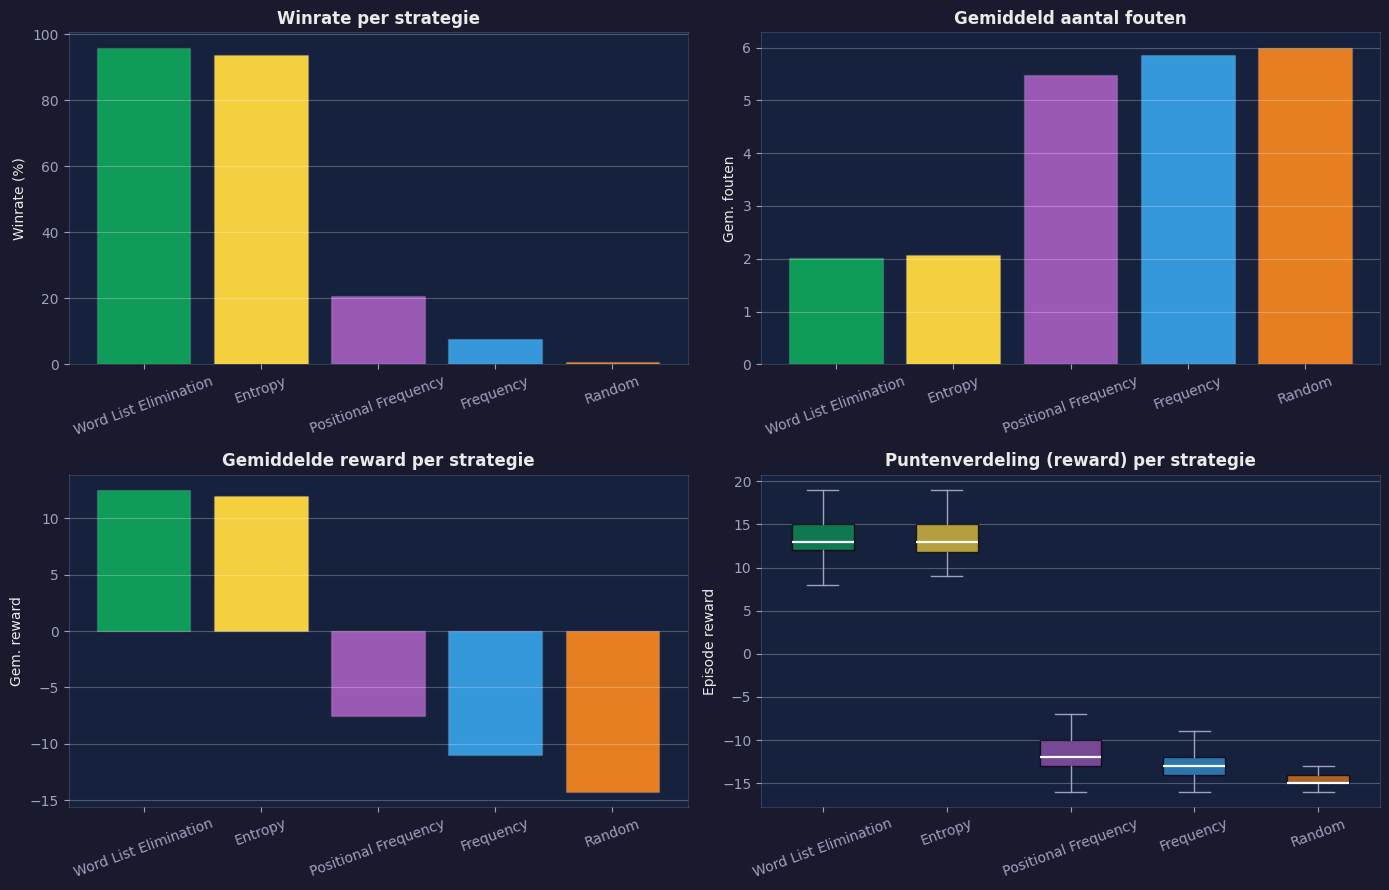

Rang,Strategie,Winrate (%),Gem. fouten,Gem. stappen,Gem. reward
1,Word List Elimination,95.80,2.02,7.38,12.51
2,Entropy,93.60,2.07,7.37,11.95
3,Positional Frequency,20.70,5.48,9.29,-7.54
4,Frequency,7.60,5.86,9.18,-11.01
5,Random,0.60,5.99,7.61,-14.25


In [5]:
AGENTS = get_all_agents()
BASE_WORDS = sorted(set(w for w in FIXED_WORDS if isinstance(w, str) and w.isalpha()))
N_EVAL = min(1000, len(BASE_WORDS))
MAX_WRONG_BASE = 6
rng_base = random.Random(42)
EVAL_WORDS_BASE = rng_base.sample(BASE_WORDS, N_EVAL)

REWARD_CONFIG = {
    "correct_reward": 1.0,
    "win_reward": 10.0,
    "wrong_penalty": -1.0,
    "lose_penalty": -10.0,
    "repeat_penalty": -2.0,
    "reveal_reward_scale": 0.0,
    "info_gain_reward_scale": 0.0,
    "step_penalty": 0.0,
}

def evaluate_agent(agent, vocab_words, eval_words, max_wrong=6):
    env = HangmanEnvironment(
        word_list=vocab_words,
        max_wrong_guesses=max_wrong,
        seed=11,
        **REWARD_CONFIG,
    )
    wins = 0
    wrong_total = 0
    steps_total = 0
    reward_samples = []

    for word in eval_words:
        obs = env.reset(word=word)
        steps = 0
        ep_reward = 0.0

        while not env.is_done and steps < 30:
            letter = agent.pick_letter(obs, vocab_words)
            result = env.step(letter)
            obs = result.observation
            ep_reward += result.reward
            steps += 1

        wins += int(env.game.is_won)
        wrong_total += env.game.wrong_guesses
        steps_total += steps
        reward_samples.append(ep_reward)

    n = max(1, len(eval_words))
    return {
        "win_rate": 100.0 * wins / n,
        "avg_wrong": wrong_total / n,
        "avg_steps": steps_total / n,
        "avg_reward": float(np.mean(reward_samples)),
        "reward_samples": reward_samples,
    }

ENV_RESULTS = []
for agent in AGENTS:
    metrics = evaluate_agent(
        agent,
        BASE_WORDS,
        EVAL_WORDS_BASE,
        max_wrong=MAX_WRONG_BASE,
    )
    ENV_RESULTS.append({"agent": agent.name, **metrics})

ENV_RESULTS = sorted(
    ENV_RESULTS,
    key=lambda x: (-x["win_rate"], -x["avg_reward"], x["avg_wrong"]),
)
BEST_AGENT_NAME = ENV_RESULTS[0]["agent"]

agent_names = [r["agent"] for r in ENV_RESULTS]
labels = [name.replace(" Agent", "") for name in agent_names]
win_vals = [r["win_rate"] for r in ENV_RESULTS]
wrong_vals = [r["avg_wrong"] for r in ENV_RESULTS]
avg_reward_vals = [r["avg_reward"] for r in ENV_RESULTS]
box_data = [r["reward_samples"] for r in ENV_RESULTS]
bar_colors = [agent_color(name) for name in agent_names]

fig, axes = plt.subplots(2, 2, figsize=(14, 9), facecolor=PALETTE["bg"])
ax1, ax2, ax3, ax4 = axes.flatten()

ax1.bar(labels, win_vals, color=bar_colors, edgecolor="#FFFFFF22")
ax1.set_title("Winrate per strategie", fontweight="bold")
ax1.set_ylabel("Winrate (%)")
style_axis(ax1, x_rotation=20, grid_axis="y")

ax2.bar(labels, wrong_vals, color=bar_colors, edgecolor="#FFFFFF22")
ax2.set_title("Gemiddeld aantal fouten", fontweight="bold")
ax2.set_ylabel("Gem. fouten")
style_axis(ax2, x_rotation=20, grid_axis="y")

ax3.bar(labels, avg_reward_vals, color=bar_colors, edgecolor="#FFFFFF22")
ax3.set_title("Gemiddelde reward per strategie", fontweight="bold")
ax3.set_ylabel("Gem. reward")
style_axis(ax3, x_rotation=20, grid_axis="y")

bp = ax4.boxplot(box_data, tick_labels=labels, patch_artist=True, showfliers=False)
for patch, col in zip(bp["boxes"], bar_colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.72)
for median in bp["medians"]:
    median.set_color("white")
    median.set_linewidth(1.6)
for whisk in bp["whiskers"]:
    whisk.set_color(PALETTE["subtext"])
for cap in bp["caps"]:
    cap.set_color(PALETTE["subtext"])
ax4.set_title("Puntenverdeling (reward) per strategie", fontweight="bold")
ax4.set_ylabel("Episode reward")
style_axis(ax4, x_rotation=20, grid_axis="y")

plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(ENV_RESULTS)[["agent", "win_rate", "avg_wrong", "avg_steps", "avg_reward"]].copy()
summary_df["Strategie"] = summary_df["agent"].str.replace(" Agent", "", regex=False)
summary_df.insert(0, "Rang", range(1, len(summary_df) + 1))
summary_df = summary_df[["Rang", "Strategie", "win_rate", "avg_wrong", "avg_steps", "avg_reward"]]
summary_df = summary_df.rename(columns={
    "win_rate": "Winrate (%)",
    "avg_wrong": "Gem. fouten",
    "avg_steps": "Gem. stappen",
    "avg_reward": "Gem. reward",
})

summary_styled = (
    summary_df.style
    .hide(axis="index")
    .format({
        "Winrate (%)": "{:.2f}",
        "Gem. fouten": "{:.2f}",
        "Gem. stappen": "{:.2f}",
        "Gem. reward": "{:.2f}",
    })
    .set_table_styles([
        {"selector": "table", "props": [("border-collapse", "collapse"), ("margin", "8px 0")]},
        {"selector": "th", "props": [
            ("background-color", PALETTE["bg"]),
            ("color", PALETTE["gold"]),
            ("border", "1px solid #FFFFFF22"),
            ("padding", "8px 10px"),
        ]},
        {"selector": "td", "props": [
            ("border", "1px solid #FFFFFF22"),
            ("padding", "7px 10px"),
        ]},
    ])
    .set_properties(**{
        "background-color": PALETTE["panel"],
        "color": PALETTE["text"],
    })
)

display(summary_styled)

## 5. Word List Elimination vs. Entropy: een gelijkwaardige strijd

Word List Elimination is een krachtige strategie omdat deze na elke gok de zoekruimte direct verkleint.

Waarom dat helpt:

- Elke nieuwe observatie (hit of mis) verwijdert meteen veel onmogelijke woorden.
- Daarna kiest de agent de letter die in de meeste overblijvende kandidaatwoorden voorkomt.
- Daardoor maximaliseert hij vroeg in het spel de kans op een **correcte** volgende gok.
- Minder missers vroeg in het spel betekent meer levens over voor latere, moeilijkere keuzes.

Entropy werkt op dezelfde informatiebasis:

- Entropy kijkt niet alleen naar hit-kans, maar ook naar **informatiewinst** van de splitsing.
- Bij grote vocabularies levert die extra informatie in theorie meer op — maar in de praktijk, na het vergroten van de woordenlijst, presteren beide strategieën **gelijkwaardig**.

In de visualisatie hieronder vergelijken we daarom bewust alleen de **laatste twee strategieën**:
**Word List Elimination** en **Entropy**, nu op grotere vocabularies tot ongeveer **30.000 woorden**.

In [ ]:
# Vergroot de woordenlijst voor een grotere schaaltest.
BASE_FOR_EXPANSION = sorted(set(w for w in FIXED_WORDS if w.isalpha() and 4 <= len(w) <= 12))
TARGET_SIZE = 50000
rng_big = random.Random(2026)

prefixes = ["re", "un", "in", "dis", "over", "under", "pre", "post", "inter", "sub", "super", "anti"]
suffixes = ["ing", "ed", "er", "est", "ly", "ness", "ment", "tion", "s", "es", "al", "ive", "able", "less"]
vowels = "aeiou"
syllables = ["ba", "be", "bi", "bo", "bu", "ca", "ce", "ci", "co", "cu", "da", "de", "di", "do", "du", "fa", "fe", "fi", "fo", "fu", "ga", "ge", "gi", "go", "gu", "la", "le", "li", "lo", "lu", "ma", "me", "mi", "mo", "mu", "na", "ne", "ni", "no", "nu", "ra", "re", "ri", "ro", "ru", "ta", "te", "ti", "to", "tu"]


def make_variant(word, rng):
    mode = rng.randint(0, 5)
    if mode == 0:
        cand = rng.choice(prefixes) + word
    elif mode == 1:
        cand = word + rng.choice(suffixes)
    elif mode == 2:
        cand = rng.choice(prefixes) + word + rng.choice(suffixes)
    elif mode == 3:
        other = rng.choice(BASE_FOR_EXPANSION)
        left = word[: max(2, len(word) // 2)]
        right = other[max(1, len(other) // 2) :]
        cand = left + right
    elif mode == 4:
        chars = list(word)
        idxs = [i for i, ch in enumerate(chars) if ch in vowels]
        if idxs:
            i = rng.choice(idxs)
            chars[i] = rng.choice(vowels)
        cand = "".join(chars)
    else:
        # Kleine lettermutatie om extra variatie te krijgen.
        chars = list(word)
        i = rng.randrange(len(chars))
        chars[i] = rng.choice("abcdefghijklmnopqrstuvwxyz")
        cand = "".join(chars)

    cand = "".join(ch for ch in cand.lower() if ch.isalpha())
    if 4 <= len(cand) <= 12:
        return cand
    return None


def make_syllable_word(rng):
    n_parts = rng.randint(2, 5)
    cand = "".join(rng.choice(syllables) for _ in range(n_parts))
    cand = "".join(ch for ch in cand.lower() if ch.isalpha())
    if 4 <= len(cand) <= 12:
        return cand
    return None


BIG_WORDS_SET = set(BASE_FOR_EXPANSION)
attempts = 0
max_attempts = 1_200_000

while len(BIG_WORDS_SET) < TARGET_SIZE and attempts < max_attempts:
    attempts += 1
    if rng_big.random() < 0.8:
        w = rng_big.choice(BASE_FOR_EXPANSION)
        new_w = make_variant(w, rng_big)
    else:
        new_w = make_syllable_word(rng_big)

    if new_w:
        BIG_WORDS_SET.add(new_w)

BIG_WORDS = sorted(BIG_WORDS_SET)
print(f"Basiswoorden: {len(BASE_FOR_EXPANSION)}")
print(f"Uitgebreide woordenlijst: {len(BIG_WORDS)}")


def win_rate_for_agent(agent, vocab_words, eval_words, max_wrong=6):
    env = HangmanEnvironment(word_list=vocab_words, max_wrong_guesses=max_wrong, seed=19)
    wins = 0

    for word in eval_words:
        obs = env.reset(word=word)
        steps = 0
        while not env.is_done and steps < 30:
            letter = agent.pick_letter(obs, vocab_words)
            result = env.step(letter)
            obs = result.observation
            steps += 1
        wins += int(env.game.is_won)

    return 100.0 * wins / max(1, len(eval_words))


# Alleen de laatste twee strategieen voor deze vergelijking.
selected_agent_names = ["Word List Elimination Agent", "Entropy Agent"]
agents_big = [a for a in get_all_agents() if a.name in selected_agent_names]

sizes = list(range(20000, 55000, 5000))
sizes = [s for s in sizes if s <= len(BIG_WORDS)]

scores = {a.name: [] for a in agents_big}
best_per_size = []

for size in sizes:
    vocab_subset = rng_big.sample(BIG_WORDS, size)
    eval_subset = rng_big.sample(vocab_subset, min(220, len(vocab_subset)))
    rows = []

    for agent in agents_big:
        wr = win_rate_for_agent(agent, vocab_subset, eval_subset, max_wrong=6)
        scores[agent.name].append(wr)
        rows.append((agent.name, wr))

    rows.sort(key=lambda x: x[1], reverse=True)
    best_per_size.append((size, rows[0][0], rows[0][1]))

    print(f"\nVocab grootte: {size}")
    for name, wr in rows:
        short_name = name.replace(" Agent", "")
        print(f"- {short_name:<24} {wr:6.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=PALETTE["bg"])
ax1, ax2 = axes

for agent in agents_big:
    y = scores[agent.name]
    ax1.plot(
        sizes,
        y,
        marker="o",
        linewidth=2.4,
        color=agent_color(agent.name),
        label=agent.name.replace(" Agent", ""),
    )

ax1.set_title("Winrate: Entropy vs Word List Elimination", fontweight="bold")
ax1.set_xlabel("Aantal woorden in vocab")
ax1.set_ylabel("Winrate (%)")
style_axis(ax1, x_rotation=0, grid_axis="both")
style_legend(ax1, fontsize=9, loc="best")

best_scores = [b[2] for b in best_per_size]
winner_names = [b[1] for b in best_per_size]
bar_colors = [agent_color(name) for name in winner_names]
ax2.bar([str(s) for s in sizes], best_scores, color=bar_colors, edgecolor="#FFFFFF22")
for i, (size, winner, score) in enumerate(best_per_size):
    ax2.text(
        i, score + 0.8,
        winner.replace(" Agent", ""),
        ha="center", va="bottom", fontsize=8, rotation=20, color=PALETTE["text"]
    )

ax2.set_title("Beste van de 2 per vocab-grootte", fontweight="bold")
ax2.set_xlabel("Vocab grootte")
ax2.set_ylabel("Beste winrate (%)")
style_axis(ax2, x_rotation=0, grid_axis="y")

plt.tight_layout()
plt.show()

BIG_VOCAB_RESULTS = {
    "sizes": sizes,
    "scores": scores,
    "best_per_size": best_per_size,
    "vocab_size": len(BIG_WORDS),
    "selected_agents": [a.name for a in agents_big],
}

## 6. Eindconclusie

In dit notebook zijn vijf rule-based agents voor Hangman ontwikkeld en vergeleken, elk met een duidelijk hogere mate van redenering dan de vorige.

### Wat laten de resultaten zien?

De progressie van strategie naar strategie is consistent zichtbaar in de benchmarkresultaten:

- **Random** vormt de ondergrens — alle andere agents presteren hier beter dan.
- **Frequentie** wint al merkbaar meer door gebruik te maken van Engelse letterfrequentie, zonder enige spelkennis.
- **Positionele Frequentie** verbetert dit verder door te kijken naar *waar* letters voorkomen, maar is nog blind voor het spelverloop.
- **Woordeliminatie** maakt de grootste sprong: door de kandidatenlijst na elke gok te filteren wordt elke volgende keuze gerichter.
- **Entropie** presteert na het vergroten van de woordenlijst **gelijkwaardig** aan Woordeliminatie. Het theoretische voordeel van informatieoptimale splitsing leidt in de praktijk niet tot een hogere winrate dan de eliminatiestrategie.

### Wanneer wint welke strategie?

| Situatie | Beste strategie |
|---|---|
| Kleine woordenlijst (< 5.000 woorden) | Word List Elimination of Entropy (gelijkwaardig) |
| Grote woordenlijst (> 10.000 woorden) | Word List Elimination of Entropy (gelijkwaardig) |
| Laatste leven over | Entropy (life-aware modus) |

### Kernbevinding

Het centrale inzicht van dit project is dat **meer informatie over het spel altijd loont**, maar dat twee manieren om die informatie te benutten tot hetzelfde resultaat kunnen leiden. Woordeliminatie en entropie gebruiken allebei dezelfde informatie (de kandidatenlijst), en blijken in de praktijk even effectief — ook bij grote vocabularies. Het theoretische voordeel van entropie (optimale informatiewinst per gok) vertaalt zich niet in een meetbaar hogere winrate.

Dit bevestigt dat het filteren van de kandidatenlijst de dominante factor is, en dat verdere optimalisatie van de letterkeuze binnen die gefilterde lijst slechts marginaal uitmaakt.

## Bronnenlijst

Cover, T. M., & Thomas, J. A. (2006). *Elements of information theory* (2nd ed.). Wiley-Interscience. https://doi.org/10.1002/047174882X

Norvig, P. (2012). *English letter frequency counts: Mayzner revisited*. https://norvig.com/mayzner.html

Shannon, C. E. (1948). A mathematical theory of communication. *Bell System Technical Journal*, *27*(3), 379–423. https://doi.org/10.1002/j.1538-7305.1948.tb01338.x

Sutton, R. S., & Barto, A. G. (2018). *Reinforcement learning: An introduction* (2nd ed.). MIT Press. http://incompleteideas.net/book/the-book-2nd.html